In [16]:
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST, CIFAR10
from cuda_acc import cpu, cuda
import numpy as np

train_dataset = CIFAR10(root='./data', train=True, download=False)
X_train = train_dataset.data

X_train.shape

(50000, 32, 32, 3)

In [2]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

cifar10 = datasets.fetch_openml('CIFAR_10', version=1, data_home='./data', parser='auto')
X = cifar10.data
y = cifar10.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=1 / 6, random_state=514)

print(X_train.shape, X_test.shape)

(50000, 3072) (10000, 3072)


In [5]:
import torch
from torchvision.datasets import MNIST, CIFAR10
from cuda_acc import cpu, cuda, has_cuda
import numpy as np
import cupy as cp


def data_filter(X, y, lib, amount=None, filter=range(10)):
    if amount is None:
        amount = len(X)
    selected_data = []
    selected_labels = []
    for label in filter:
        label_indices = lib.where(y == label)[0]
        selected_indices = label_indices[:amount]
        selected_data.append(X[selected_indices])
        selected_labels.append(y[selected_indices])
    X = lib.concatenate(selected_data, axis=0)
    y = lib.concatenate(selected_labels, axis=0)
    rperm = lib.random.permutation(X.shape[0])
    X = X[rperm]
    y = y[rperm]
    return X, y


def load_data(data_type, data_path='./data', device=cuda):
    X_train, y_train, X_test, y_test = None, None, None, None
    lib = np if device is cpu else cp
    if data_type == 'mnist':
        train_dataset = MNIST(root=data_path, train=True, download=True)
        X_train = train_dataset.data.reshape(train_dataset.data.shape[0], -1)
        y_train = train_dataset.targets.reshape(train_dataset.targets.shape[0], -1)

        test_dataset = MNIST(root=data_path, train=False)
        X_test = test_dataset.data.reshape(test_dataset.data.shape[0], -1)
        y_test = test_dataset.targets.reshape(test_dataset.targets.shape[0], -1)

    elif data_type == 'cifar10':
        train_dataset = CIFAR10(root=data_path, train=True, download=True)
        X_train = torch.tensor(train_dataset.data).reshape(len(train_dataset), -1)
        y_train = torch.tensor(train_dataset.targets).reshape(len(train_dataset), -1)

        test_dataset = CIFAR10(root=data_path, train=False)
        X_test = torch.tensor(test_dataset.data).reshape(len(test_dataset), -1)
        y_test = torch.tensor(test_dataset.targets).reshape(len(test_dataset), -1)

    X_train, y_train, X_test, y_test = device(X_train), device(y_train), device(X_test), device(y_test)

    X_train, y_train = data_filter(X_train, y_train, lib, 500)
    X_test, y_test = data_filter(X_test, y_test, lib, 100)

    print('Data Loaded.')

    return X_train, y_train, X_test, y_test


a, b, c, d = load_data('cifar10')


def label_wash(label, lib):
    unique_labels = lib.unique(label)  # 查找唯一的标签
    if len(unique_labels) != 2:
        raise ValueError('Include more than one classes.')
    l_converted = lib.where(label == max(unique_labels), 1, -1)
    return l_converted


cp.array([[1, 2], [2, 3], [4, 5]]) - cp.array()

Files already downloaded and verified
Data Loaded.


array([[0, 0],
       [1, 1],
       [3, 3]], dtype=int32)

In [29]:

class MDS:
    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit_reduce(self, data, dev=cuda):
        lib = np if dev is cpu else cp
        size = len(data)
        dist = lib.zeros((size, size))  # distance matrix D. here is actually dist_ij^2, no need to sqrt
        dist_i = lib.zeros(size)  # also square dist
        dist_j = lib.zeros(size)
        for i in range(size):
            print(data[i] - data)
            dist[i] = lib.sum(lib.square(data[i] - data), axis=1).T
        dist_ij = lib.mean(dist)
        for k in range(size):
            dist_i[k] = lib.mean(dist[k])
            dist_j[k] = lib.mean(dist[:, k])
        B = lib.zeros((size, size))
        for i in range(size):
            for j in range(size):
                B[i][j] = -0.5 * (dist[i][j] - dist_i[i] - dist_j[j] + dist_ij)
        eigenvalues, eigenvectors = lib.linalg.eigh(B)
        index = lib.argsort(-eigenvalues)[:self.n_components]
        diag_eigenvalues = lib.sqrt(lib.diag(-lib.sort(-eigenvalues)[:self.n_components]))
        selected_v = eigenvectors[:, index]
        Z = selected_v.dot(diag_eigenvalues)
        return Z


# principal component analysis
# param:
#   same as MDS, no dis
# method:
#   same as MDS
class PCA:
    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit_reduce(self, data, dev=cuda):
        lib = np if dev is cpu else cp
        centre = lib.mean(data, axis=0)
        data = data - centre  # zero centred
        cov = lib.cov(data.T)
        eigenvalues, eigenvectors = lib.linalg.eigh(cov)
        index = lib.argsort(eigenvalues)[-self.n_components:]  # sort from big to small
        selected_v = eigenvectors[:, index]
        W = data.dot(selected_v)
        return lib.fliplr(W)  # flip to look better


data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

mds = MDS(n_components=2)
Z_mds = mds.fit_reduce(data, dev=cpu)

print("MDS result:")
print(Z_mds.shape)

pca = PCA(n_components=2)
W_pca = pca.fit_reduce(data, dev=np)

print("PCA result:")
print(W_pca.shape)


[[ 0  0  0]
 [-3 -3 -3]
 [-6 -6 -6]]
[[ 3  3  3]
 [ 0  0  0]
 [-3 -3 -3]]
[[6 6 6]
 [3 3 3]
 [0 0 0]]
MDS result:
(3, 2)


TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

In [70]:
import numpy as np
from scipy.ndimage import convolve


def calculate_hog(image, lib):
    gray = lib.dot(image[..., :3], lib.array([0.2989, 0.5870, 0.1140]))
    gray = gray.get() if lib is cp else gray
    dx = lib.array(convolve(gray, np.array([[-1, 0, 1]])))
    dy = lib.array(convolve(gray, np.array([[-1], [0], [1]])))
    magnitude = lib.sqrt(dx ** 2 + dy ** 2)
    angle = lib.arctan2(dy, dx)
    angle = lib.rad2deg(angle) % 180
    block_size = 8
    cell_size = 4
    num_bins = 9
    hog_feature = []
    for i in range(0, gray.shape[0] - block_size + 1, cell_size):
        for j in range(0, gray.shape[1] - block_size + 1, cell_size):
            block = magnitude[i:i + block_size, j:j + block_size]
            block_angle = angle[i:i + block_size, j:j + block_size]
            hist, _ = lib.histogram(block_angle, bins=num_bins, range=(0, 180), weights=block)
            hog_feature.append(hist)
    hog_vector = lib.array(hog_feature).flatten()
    return hog_vector


def hog_features(images, dev=cuda):
    lib = np if dev is cpu else cp
    hog_batch = []
    for image in images:
        hog_vector = calculate_hog(image, lib)
        hog_batch.append(hog_vector)
    return lib.array(hog_batch)


images = np.random.rand(1000, 32, 32, 3)
hog_features = hog_features(images, dev=cpu)

print(hog_features.shape)


(1000, 441)


In [91]:
import numpy as np
np.linalg.norm(np.ones((32,32))*255)

8160.0

In [74]:
import pickle


class MyClass:
    def __init__(self, data):
        self.data = data

    def __getstate__(self):
        state = self.__dict__.copy()
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)

    def save(self, file_path):
        with open(file_path, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def load(file_path):
        with open(file_path, 'rb') as f:
            obj = pickle.load(f)
        return obj


class C(MyClass):
    def __init__(self, data1):
        self.data1 = data1


obj = C(data1='Hello')
obj.save('my_obj.pkl')
loaded_obj = C.load('my_obj.pkl')
print(loaded_obj.data1)


Hello


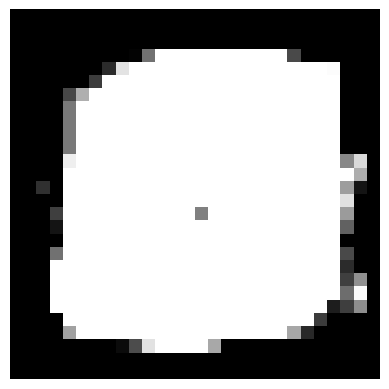

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

mnist_dataset = datasets.MNIST(root='./data', train=True, download=True)
mnist_data = mnist_dataset.data.numpy()
mnist_labels = mnist_dataset.targets.numpy()
ones_data = mnist_data[mnist_labels == 0][:500]
sum_image = np.sum(ones_data, axis=0)
sum_image = np.clip(sum_image, 0, 255).astype(np.uint8)

plt.imshow(sum_image, cmap='gray')
plt.axis('off')
plt.show()


In [ ]:
from cuda_acc import cuda
from data_loader import data_filter, load_data
from SVM import SVM151, SVC151, MKLSVM151
import cupy as cp
import time
import torch
import numpy as np
from img_process import PCA, histo_gram, mathcal_fetures, rgb_vector, hog_features
def set_seeds(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    cp.random.seed(seed)
set_seeds(10)
# a, b, c, d = load_data('cifar10')  # 32,32,3
# a = cp.concatenate((a, histo_gram(a, 16), mathcal_fetures(a), rgb_vector(a), hog_features(a)), axis=1)
# c = cp.concatenate((c, histo_gram(c, 16), mathcal_fetures(c), rgb_vector(c), hog_features(c)), axis=1)
a, b, c, d = load_data('mnist')
a = cp.concatenate((a, histo_gram(a, 2), mathcal_fetures(a)), axis=1)
c = cp.concatenate((c, histo_gram(c, 2), mathcal_fetures(c)), axis=1)
pca = PCA(512)
a = pca.fit_reduce(a, cuda)
c = pca.reduce(c)

x, y = data_filter(a, b, cp, filter=[1])
z, w = data_filter(c, d, cp, filter=[1])
# x = cp.array([[-1, 2], [-1, 3], [20, 2], [20, 3]])
# y = cp.array([[0], [0], [1], [1]])
# z = cp.array([[-1, 4], [-1, 5], [20, 4], [20, 5]])
# w = cp.array([[0], [0], [1], [1]])
# x = x - x.mean(0)
# z = z - z.mean(0)
# print(x.shape, y.shape, z.shape)


# svm = SVM151(cuda)
# # svm.fit(x, y, kernel='rbf', epochs=100, step_lambda=0.001, kernel_args=(0.001, cp))
# svm.fit(x, y, kernel='poly', epochs=100, step_lambda=0.01, kernel_args=(1, 2))
# print(svm.test(x, y))
# print(svm.test(z, w))


# svm = MKLSVM151(cuda)
# svm.fit(x, y, epochs=200, step_lambda=0.01)
# # svm.fit(x, y, kernel='poly', epochs=100, step_lambda=0.01, kernel_args=(1, 2))
# print(svm.test(x, y))
# print(svm.test(z, w))

# svm = SVM151(cuda)
# svm.fit(x, y, kernel='linear', epochs=200, step_lambda=0.01)
# # svm.fit(x, y, kernel='poly', epochs=200, step_lambda=0.1)
# print(svm.test(x, y))()

# print(svm.test(z, w))

# x, y = data_filter(a, b, cp, filter=[1])
# z, w = data_filter(c, d, cp, filter=[1])
#
# svm = SVM151(cuda)
# svm.fit(x, y, kernel='linear', epochs=300, step_lambda=0.1, cache_size=5000)
# # svm.fit(x, y, kernel='poly', epochs=3000, step_lambda=0.1)
# print(svm.test(x, y))
# print(svm.test(z, w))

# exit(0)


# t = time.time()
# svc = SVC151(cuda, num_classes=10, mode=0)
# # svc.fit(a, b, epochs=200, kernel='rbf', step_lambda=0.001, kernel_args=(0.001, cp))
# svc.fit(a, b, epochs=200, kernel='poly', step_lambda=0.01, cache_size=256)
# # svc.fit(a, b, epochs=1000, kernel='linear', step_lambda=0.1)
# print(svc.test(c, d))
# print(time.time() - t)

t = time.time()
svc = SVC151(cuda, num_classes=10, mode=0, multi_kernel=True)
svc.fit(a, b, epochs=200, step_lambda=0.01, cache_size=256)
print(svc.test(c, d))
print(time.time() - t)

# t = time.time()
# svc = SVC151(cuda, num_classes=10, mode=1)
# # svc.fit(a, b, epochs=200, kernel='rbf', step_lambda=0.01)
# svc.fit(a, b, epochs=200, kernel='poly', step_lambda=0.01, cache_size=256)
# # svc.fit(a, b, epochs=5000, kernel='linear', step_lambda=0.1)
# print(svc.test(c, d))
# print(time.time() - t)
#
# t = time.time()
# svc = SVC151(cuda, num_classes=10, mode=1, multi_kernel=True)
# svc.fit(a, b, epochs=200, step_lambda=0.01, cache_size=256)
# print(svc.test(c, d))
# print(time.time() - t)
